# Lecture 4 演習(アンケート結果の可視化)

第１回講義にて、簡単なアンケートを取りました。教員は、この結果はエクセルとしてダウンロードできます。

エクセル形式で保存されたアンケート結果を集計分析する例を、できるだけインタラクティブに再現してみました。

## エクセルを読む
最初にエクセル形式のファイル(ここでは*.xlsという古い形式のデータを読みます)

ファイルはmanabaに掲載しますので、ダウンロードしてからCorab環境にuploadしてください。

In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel('https://raw.githubusercontent.com/miwamasa/DataScience2026/main/notebooks/data/query-107633-108363.xls',skiprows=4)
df

,#title role,grade,symgrade,comment,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,# ロール,# 合計点,# 評価,# 講評,# 経過時間,# 提出,# 提出日時,# 回答1.1,# 回答1.2,# 回答1.3,# 回答1.4,# 回答1.5
1,履修生,NaN,NaN,NaN,NaN,未提出,NaN,NaN,NaN,NaN,NaN,NaN
2,履修生,NaN,NaN,NaN,NaN,未提出,NaN,NaN,NaN,NaN,NaN,NaN
3,履修生,NaN,NaN,NaN,NaN,未提出,NaN,NaN,NaN,NaN,NaN,NaN
4,履修生,NaN,NaN,NaN,NaN,未提出,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
265,担当教員,NaN,NaN,NaN,NaN,未提出,NaN,NaN,NaN,NaN,NaN,NaN
266,担当教員,NaN,NaN,NaN,NaN,未提出,NaN,NaN,NaN,NaN,NaN,NaN
267,担当教員,NaN,NaN,NaN,NaN,未提出,NaN,NaN,NaN,NaN,NaN,NaN
268,担当教員,NaN,NaN,NaN,NaN,未提出,NaN,NaN,NaN,NaN,NaN,NaN


どうも第１行が、カラム名で、第２行はその説明、３行目以降が一人一人のアンケートのようです。

とりあえず２つを行います
- 取り扱うコラムは#回答1.1～回答1.4ですので、名前をつけなおします。(df.columnsにリストを代入すればコラム名は付け替えられました)
- 最初の２行を読み飛ばします(行に対するスライスを使ってます。)

In [2]:
df_head = df[['Unnamed: 6','Unnamed: 7','Unnamed: 8','Unnamed: 9','Unnamed: 10']]
df_head.columns=['dateof','q1.1','q1.2','q1.3','q1.4']

df_head=df_head[2:]
df_head.head()

,dateof,q1.1,q1.2,q1.3,q1.4
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN


未提出でNaNの行ももあり、また最後の行がNaNで埋まっています、

全てがNaNの行を削除しましょう。

In [3]:
df2=df_head.dropna(how='all')
df2

,dateof,q1.1,q1.2,q1.3,q1.4
10,2026-04-07 20:31:16,2,3,2,"2,3"
15,2026-04-07 21:37:31,3,"1,2,3,5,8",2,"1,2,3"
53,2026-04-07 20:35:10,6,10,3,2
69,2026-04-07 21:29:13,6,10,3,4
92,2026-04-07 20:18:03,1,"3,8",2,1
96,2026-04-07 21:36:49,3,3,2,2
120,2026-04-07 20:05:21,1,"3,5",2,"1,2,3,5"
126,2026-04-09 07:21:54,4,10,3,"1,2"
129,2026-04-08 18:27:08,3,"1,2,3",2,"1,2,3,4"
133,2026-04-07 20:18:05,1,"3,4",2,"1,2"


NaNがのこっています。１つでもNaNがある行を削除しましょう

In [4]:
df2=df2.dropna()
df2

,dateof,q1.1,q1.2,q1.3,q1.4
10,2026-04-07 20:31:16,2,3,2,"2,3"
15,2026-04-07 21:37:31,3,"1,2,3,5,8",2,"1,2,3"
53,2026-04-07 20:35:10,6,10,3,2
69,2026-04-07 21:29:13,6,10,3,4
92,2026-04-07 20:18:03,1,"3,8",2,1
96,2026-04-07 21:36:49,3,3,2,2
120,2026-04-07 20:05:21,1,"3,5",2,"1,2,3,5"
126,2026-04-09 07:21:54,4,10,3,"1,2"
129,2026-04-08 18:27:08,3,"1,2,3",2,"1,2,3,4"
133,2026-04-07 20:18:05,1,"3,4",2,"1,2"


## データの概要
さて質問は
- q1.1: 統計を学んだ経験について（複数選択）
- q1.2: 使ったことのあるプログラミング言語（複数選択)
- q1.3: Pythonを使った経験（３択）
- q1.4: データサイエンスに期待する項目は？(複数選択)

このように、複数選択可能なものがあり'1,2,3'のような文字列で複数選択結果が記録されています。

## q1.2　使ったことのあるプログラミング言語
まずは、複数選択された結果を含めて、使ったことのあるプログラミング言語の延べ数を集計します。

最初に、'q1.2'の列を取り出します。

In [5]:
df2['q1.2'].values

array(['3', '1,2,3,5,8', '10', '10', '3,8', '3', '3,5', '10', '1,2,3',
       '3,4', '10', '5,8', '1,3', '1,3,5', '1,2,3,5,7,9', '1,3,4,9',
       '3,9', '1,3,5', '3,4,5', '1,2,3,5', '2', '1,3', '3,6', '2,3,9',
       '3', '3,6,8', '1,2,3,6,8', '1,3', '10', '3', '1,2,9', '1,3', '2,5',
       '3', '1,2,8', '2,3,5', '2', '3,5', '1,3,7', '10', '2,6'],
      dtype=object)

'1,2,3'のような文字列を特定のセパレータ(ここでは',')でばらしたリストにするのにsplit()関数を追加います。

In [6]:
hoge='1,2,3'
hogehoge=hoge.split(',')
hogehoge

['1', '2', '3']

そて、q1.2列の値のリストに対して、それぞれの要素をsplit関数でバラバラにして、それを１つのリストとして集約します。

ここでは**残念ながら** for文を使っています。

In [7]:
ret=[]
q2list= df2['q1.2'].values
for i in range(len(q2list)):
  ret.extend(q2list[i].split(','))
ret

['3',
 '1',
 '2',
 '3',
 '5',
 '8',
 '10',
 '10',
 '3',
 '8',
 '3',
 '3',
 '5',
 '10',
 '1',
 '2',
 '3',
 '3',
 '4',
 '10',
 '5',
 '8',
 '1',
 '3',
 '1',
 '3',
 '5',
 '1',
 '2',
 '3',
 '5',
 '7',
 '9',
 '1',
 '3',
 '4',
 '9',
 '3',
 '9',
 '1',
 '3',
 '5',
 '3',
 '4',
 '5',
 '1',
 '2',
 '3',
 '5',
 '2',
 '1',
 '3',
 '3',
 '6',
 '2',
 '3',
 '9',
 '3',
 '3',
 '6',
 '8',
 '1',
 '2',
 '3',
 '6',
 '8',
 '1',
 '3',
 '10',
 '3',
 '1',
 '2',
 '9',
 '1',
 '3',
 '2',
 '5',
 '3',
 '1',
 '2',
 '8',
 '2',
 '3',
 '5',
 '2',
 '3',
 '5',
 '1',
 '3',
 '7',
 '10',
 '2',
 '6']

さあ、ここで、得られたリストの値は、カテゴリー変数とよばれれる変数です、'1'～'10'のカテゴリー毎に出現件数を集計するのにcollection.Counterを使います。

In [8]:
import collections

c=collections.Counter(ret)
c

Counter({'3': 28,
         '1': 15,
         '2': 13,
         '5': 11,
         '8': 6,
         '10': 6,
         '9': 5,
         '6': 4,
         '4': 3,
         '7': 2})

Counterは一種の辞書dictになっています。ここでキーを'1','2'ではなくて、設問にあった選択枝'VBA','C/C++'で付け替えます。

pop(key)でkeyに対する値を得つつ、keyを辞書から削除し、すぐに、新しい名前のkeyを辞書に追加しています。一行で、keyの名前が付け替えられていることに注意ください。

In [9]:
c['VBA']=c.pop('1')
c['C/C++']=c.pop('2')
c['Python']=c.pop('3')
c['Ruby']=c.pop('4')
c['Java']=c.pop('5')
c['FORTRAN']=c.pop('6')
c['COBOL']=c.pop('7')
c['Basic']=c.pop('8')
c['Other']=c.pop('9')
c['Non']=c.pop('10')
c

Counter({'Python': 28,
         'VBA': 15,
         'C/C++': 13,
         'Java': 11,
         'Basic': 6,
         'Non': 6,
         'Other': 5,
         'FORTRAN': 4,
         'Ruby': 3,
         'COBOL': 2})

In [10]:
c.items()

dict_items([('VBA', 15), ('C/C++', 13), ('Python', 28), ('Ruby', 3), ('Java', 11), ('FORTRAN', 4), ('COBOL', 2), ('Basic', 6), ('Other', 5), ('Non', 6)])

In [11]:
c.values()

dict_values([15, 13, 28, 3, 11, 4, 2, 6, 5, 6])

## 円グラフの表示
それでは円グラフを描いてみましょう

Text(0.5, 1.0, 'Programming Language  Experience')

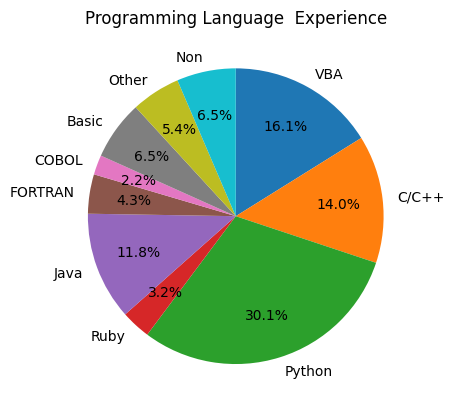

In [12]:
import matplotlib.pyplot as plt

plt.pie(c.values(),labels=c.keys(), counterclock=False, startangle=90, autopct="%.1f%%",
        pctdistance=0.7)
plt.title('Programming Language  Experience')

In [ ]:
len(q2list)

## q1.3 Pythonを使った経験
これは、３択なので簡単です。

In [13]:
df2['q1.3']

10     2
15     2
53     3
69     3
92     2
96     2
120    2
126    3
129    2
133    2
134    3
135    2
137    2
139    2
145    2
146    2
156    2
163    1
170    2
180    2
181    3
182    2
183    2
185    2
186    2
190    2
191    2
193    2
196    3
200    2
201    3
202    2
203    2
204    2
205    3
206    2
207    3
209    2
211    2
235    3
243    3
Name: q1.3, dtype: object

In [14]:
c3=collections.Counter(df2['q1.3'])
c3

Counter({'2': 29, '3': 11, '1': 1})

In [28]:
c3['over 3years']=c3.pop('1')
c3['less than 3years']=c3.pop('2')
c3['no python']=c3.pop('3')
c3

Counter({'less than 3years': 29, 'no python': 11, 'over 3years': 1})

Text(0.5, 1.0, 'Python Experience')

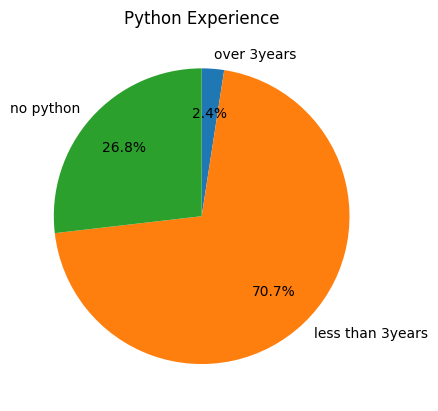

In [29]:
#plt.rcParams['font.family'] = 'IPAexGothic'
plt.pie(c3.values(),labels=c3.keys(), counterclock=False, startangle=90, autopct="%.1f%%",
        pctdistance=0.7)
plt.title('Python Experience')

## q1.1　統計を学んだ経験
これも、複数選択された結果を集計します。


In [16]:
df2['q1.1']

10       2
15       3
53       6
69       6
92       1
96       3
120      1
126      4
129      3
133      1
134      6
135      1
137      1
139      5
145      2
146    2,5
156      3
163    1,5
170    4,5
180      6
181      2
182      5
183      5
185    1,2
186    2,4
190    2,5
191      2
193    2,5
196      6
200      5
201      5
202      5
203      6
204      2
205    1,2
206      2
207      6
209      2
211      5
235      1
243      6
Name: q1.1, dtype: object

In [17]:
q1list= df2['q1.1'].ravel()
ret=[]
for i in range(len(q1list)):
  ret.extend(q1list[i].split(','))
ret

['2',
 '3',
 '6',
 '6',
 '1',
 '3',
 '1',
 '4',
 '3',
 '1',
 '6',
 '1',
 '1',
 '5',
 '2',
 '2',
 '5',
 '3',
 '1',
 '5',
 '4',
 '5',
 '6',
 '2',
 '5',
 '5',
 '1',
 '2',
 '2',
 '4',
 '2',
 '5',
 '2',
 '2',
 '5',
 '6',
 '5',
 '5',
 '5',
 '6',
 '2',
 '1',
 '2',
 '2',
 '6',
 '2',
 '5',
 '1',
 '6']

In [25]:
c1=collections.Counter(ret)
c1

Counter({'2': 13, '5': 12, '1': 9, '6': 8, '3': 4, '4': 3})

In [26]:
c1['HighSchool']=c1.pop('1')
c1['University']=c1.pop('2')
c1['GradSchool']=c1.pop('3')
c1['OJT']=c1.pop('4')
c1['SelfTaught']=c1.pop('5')
c1['NoStatistics']=c1.pop('6')
#c1['Other']=c1.pop('7')

In [ ]:
c1

Text(0.5, 1.0, 'Statistic Course Experience')

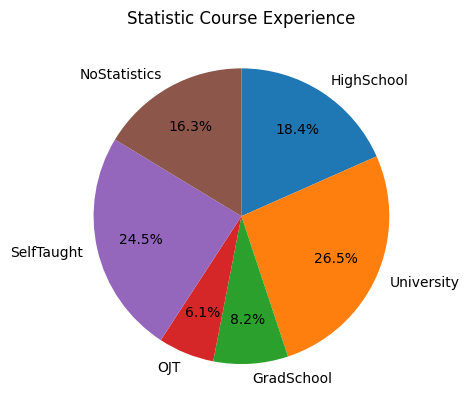

In [27]:
plt.pie(c1.values(),labels=c1.keys(), counterclock=False, startangle=90, autopct="%.1f%%",
        pctdistance=0.7)
plt.title('Statistic Course Experience')